<a href="https://colab.research.google.com/github/Kyle-Foisy/SYSC-4806/blob/master/W2026/Assignments/A2/A2_SYSC4415_W26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SYSC4415 W26 Assignment 2 – Fire Hydrant Detection 🚒

Special thanks to Nader Ibrahim for assembling the dataset. For more details, please refer to the paper:

Ibrahim N, Dick K, Green JR. Computer Vision Fire Hydrant Obstruction Detection System. In2024 IEEE Canadian Conference on Electrical and Computer Engineering (CCECE) 2024 Aug 6 (pp. 799-805). IEEE.


Questions? Please use the Brightspace Discussion Board.

Deadline: See Brightspace end date.

## Instructions
DO NOT wait until the last minute to complete this assignment as training the models might take longer. Also leverage the free GPU provided by colab to make your training faster.


Follow all steps carefully. Your solutions must be self-contained in this notebook. No other supplementary materials or files will be accepted. As soon as I open your notebook, I will click "Runtime" → "Run all". Ensure your notebook runs without errors and displays results clearly.


You are asked to provide both code and text to address discussion questions. For the text answers, see the markdown cells with the ❓ emoji for questions and enter your answers following the ✅ emoji.

Provide sufficient comments in your code to describe its functionality. Do not remove any necessary libraries as this will cause errors.

Download the dataset from Brightspace and store it in your Google Drive under "My Drive" (not in any subfolder). Check the file location via right-click → File Information → Details → Location.

Submit your notebook as a `.ipynb` file named: `SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb` on Brightspace. No other submission methods will be accepted.


## Dataset
Provided on Brightspace.

#### Dataset details:
- Training Images: 2,272  
- Validation Images: 563  
- Labels: 0 = No Fire Hydrant, 1 = Fire Hydrant  
- Imbalanced dataset (most images do not contain a hydrant).

#### Dataset Information
The dataset contains two main folders:
- `train/`: Contains the training images and a CSV file with labels.
- `valid/`: Contains the validation images and a CSV file with labels.

Each folder includes:
- Images of fire hydrants and non-fire hydrants.
- A CSV file (`_classes.csv`) mapping each image filename to its label:
  - `0` for no fire hydrant.
  - `1` for fire hydrant.

Ensure the zip file of the dataset (FH_detection_data.zip) to your Google Drive and placed under "My Drive" without any subfolders to keep the paths consistent.



## Steps

### 1) Initial Setup
Import necessary libraries


In [1]:
# Import all the necessary libraries here

import pandas as pd
import os

Mount Google Drive and unzip the dataset.

In [2]:
## Code provided by TA. DO NOT CHANGE THIS CELL

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
!unzip /content/drive/MyDrive/FH_detection_data.zip -d /content/


# Dataset path
train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')

Mounted at /content/drive
Archive:  /content/drive/MyDrive/FH_detection_data.zip
   creating: /content/train/
 extracting: /content/train/10063782964_891eedde4e_z_jpg.rf.4caba9d0e35546b469aa896df780d833.jpg  
 extracting: /content/train/100_PNG.rf.d52fbff94c483761d0644a1e8abe4c95.jpg  
 extracting: /content/train/101_PNG.rf.f1335e18f815c8c8044a94c09db7f025.jpg  
 extracting: /content/train/102378468_d8132a415b_z_jpg.rf.6bc008d0d532d3365f580b7aaa7623e3.jpg  
 extracting: /content/train/102_PNG.rf.160c945e0881c92a078a14069d9a6b9a.jpg  
 extracting: /content/train/102_jpg.rf.17df75e9dda0f851c9f5e1d554f07488.jpg  
 extracting: /content/train/103357395_388d701e12_z_jpg.rf.a54c985e93402af49ba422f005e702d8.jpg  
 extracting: /content/train/103_jpg.rf.a649213f3998906bf2298607f82ee839.jpg  
 extracting: /content/train/104351403_25e959f878_z_jpg.rf.43156bd0a74313df69967d88e5e6a268.jpg  
 extracting: /content/train/104_PNG.rf.c14671a6a52ae05f9ae2bf1df7e4316e.jpg  
 extracting: /content/train/104_

----

### 2) Data Exploration
1. Load dataset into a pandas DataFrame.
2. Display display three sample images from each class
3. Create separately class distribution plots of the train and validation data
[Requires 6 sample images (three from each class) and two plots of class distribution (train and validation)]

❓ Why is it important to check for class imbalance before training? How might this affect our model?  
✅ Your answer here
..
It is important to check for class imbalance before training because an imbalanced dataset may
lead to inaccurate and/or biased results. Additionally, the model may appear better at predicting than
it actually is because it will be more likely to guess the larger dataclass correctly. For example, in the event our
validation dataset is also unbalanced such that we have a 90 images without hydrants and 10 with hydrants, then
the model may accurately predict 88 of the images with fire hydrants and only 2 images without fire hydrant, giving us
a 90% overall accuracy despite incorrectly identifying 80% of images with fire hydrants.


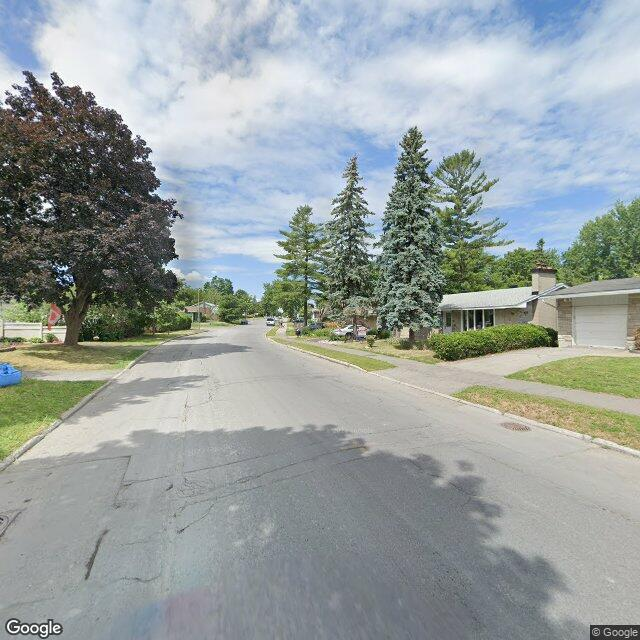

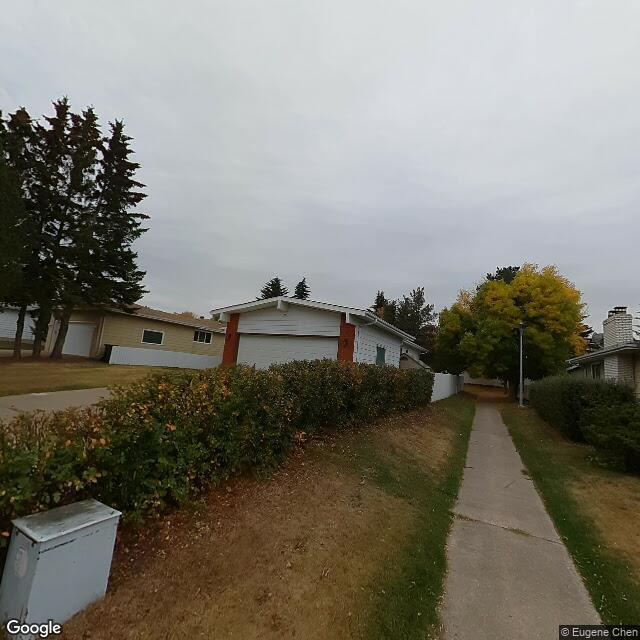

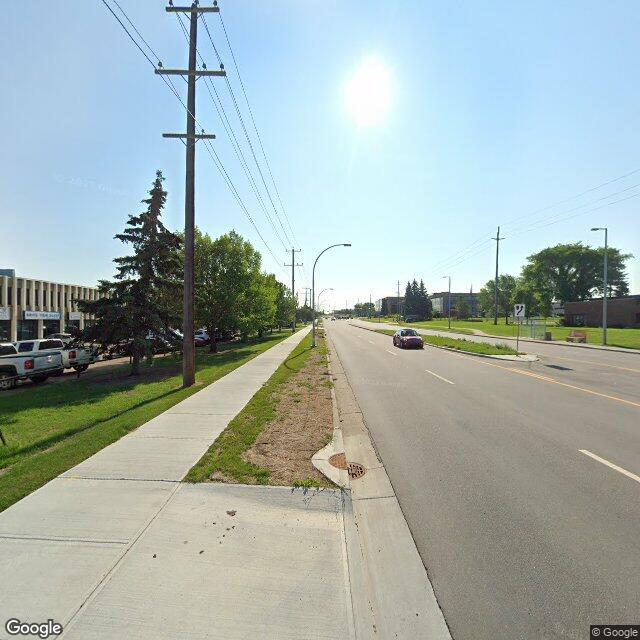

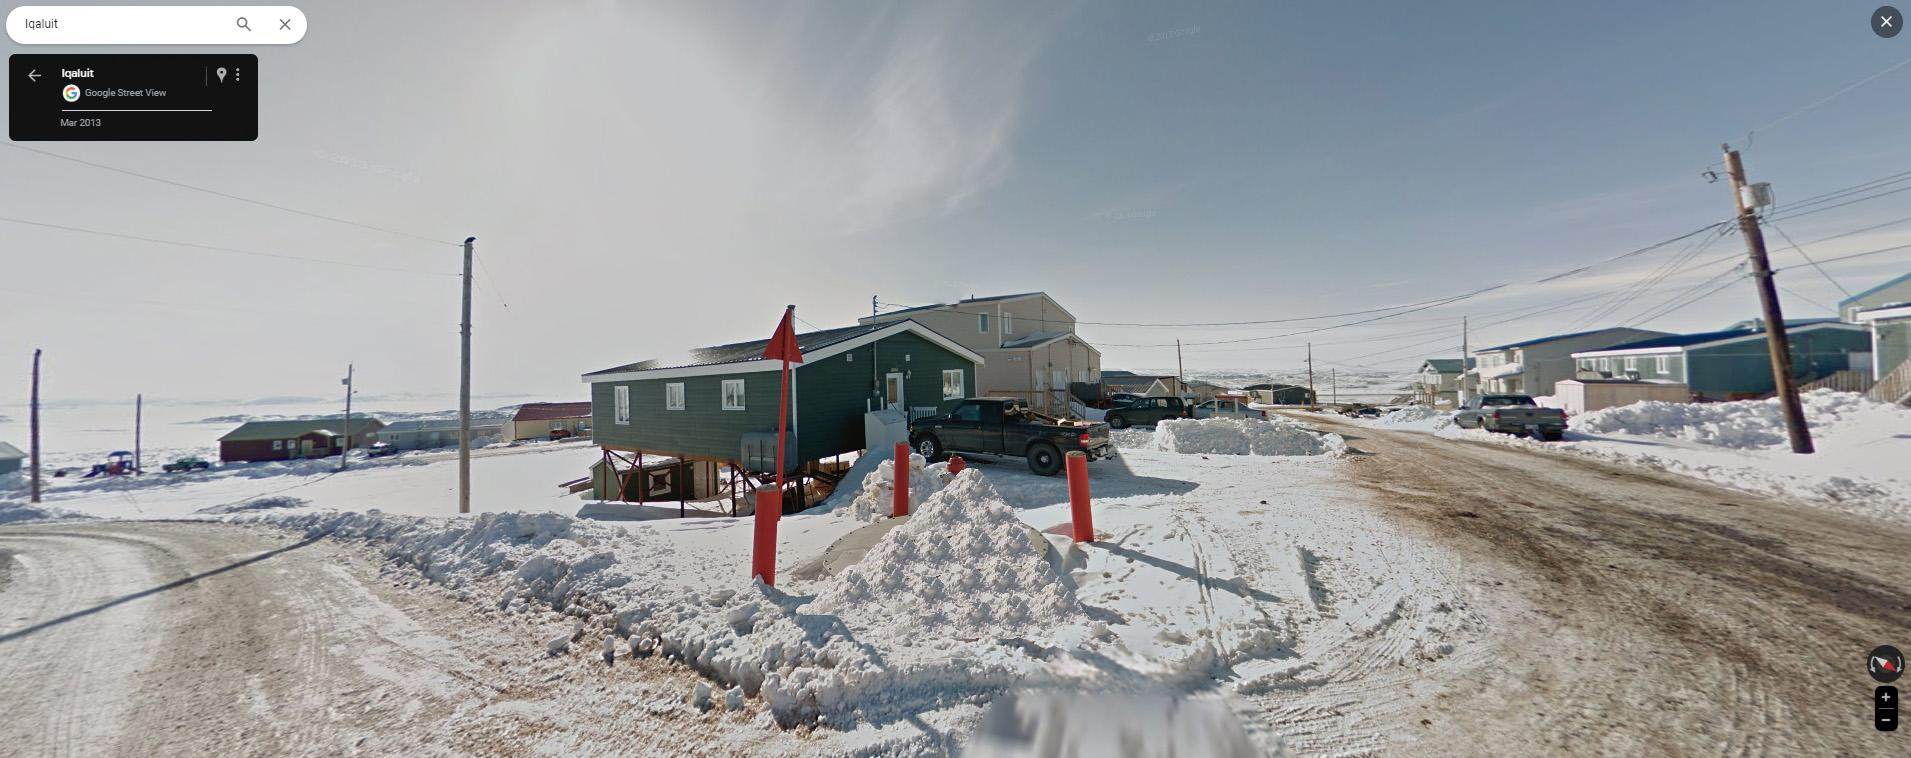

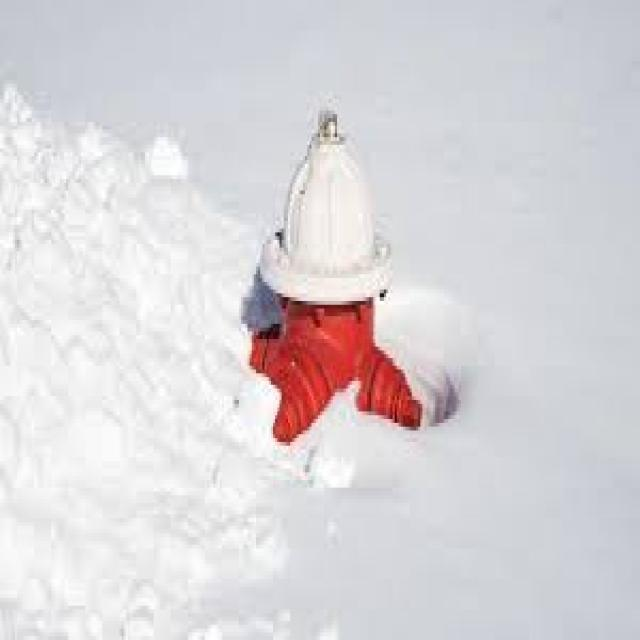

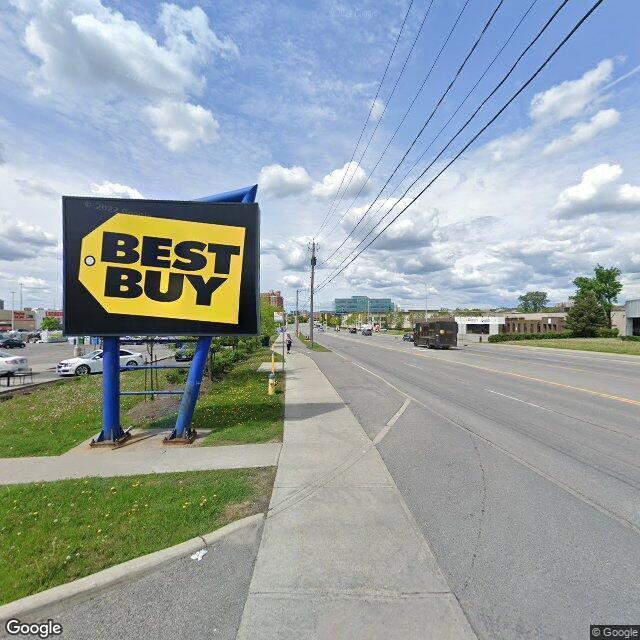

Text(0.5, 1.0, 'Testing Data')

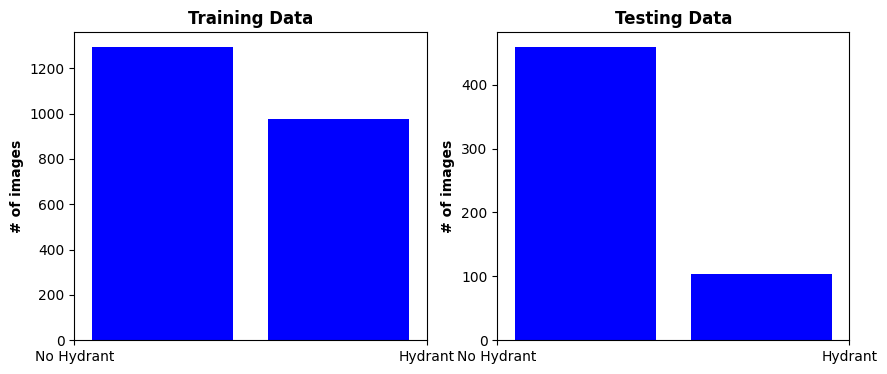

In [3]:
from IPython.display import Image as IPythonImage, display
import os
import matplotlib.pyplot as plt
import numpy as np

training_data = pd.read_csv('/content/train/_classes.csv')
trainX = training_data['filename']
trainY = training_data['Fire Hydrants']

validation_data = pd.read_csv('/content/valid/_classes.csv')
testX = validation_data['filename']
testY = validation_data['Fire Hydrants']


#Display Images Without Fire Hydrants
displayed = 0
i = 0
while displayed < 3 and i < len(training_data):
  if trainY[i] == 0:
    display(IPythonImage(os.path.join(train_data_path, trainX[i])))
    displayed += 1
  i += 1


#Display Images With Fire Hydrants
displayed = 0
i = 0
while displayed < 3 and i < len(training_data):
  if trainY[i] == 1:
    display(IPythonImage(os.path.join(train_data_path, trainX[i])))
    displayed += 1
  i += 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#Plot distribution of training data
temp = training_data['Fire Hydrants'].to_numpy()
axes[0].hist(temp, bins=2, color="blue", rwidth=0.8)
axes[0].set_xticks([0,1], ["No Hydrant", "Hydrant"])
axes[0].set_ylabel("# of images", weight='bold')
axes[0].set_title("Training Data", weight='bold')

#Plot distribution of test data
temp = validation_data['Fire Hydrants'].to_numpy()
axes[1].hist(temp, bins=2, color="blue", rwidth=0.8)
axes[1].set_xticks([0,1], ["No Hydrant", "Hydrant"])
axes[1].set_ylabel("# of images", weight='bold')
axes[1].set_title("Testing Data", weight='bold')

---

### 3) Preprocessing
- Resize images to 128x128.
- Apply any other necessary transformations that you feel can help.

❓ Would one-hot encoding be necessary for binary classification? Why or why not?  
✅ Your answer here..

one-hot encoding would not be strictly necessary for binary classification.
The purpose of one-hot encoding to to convert classifications to a binary array representation of the classifications where each classification is one column in the array.
But because our system is a binary classification. we already effectively have this binary array representation, just with 1 column, either we have a fire hydrant, or we don't.

In [4]:
## Enter your code here..
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

#Disable warnings about re-assigning pandas values
pd.options.mode.chained_assignment = None

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

for i in range(len(trainX)):
   temp = Image.open(os.path.join(train_data_path, trainX[i]))
   temp = temp.convert('RGB')
   trainX[i] = transform(temp)

trainY = torch.tensor(trainY)

training_set = list(zip(trainX, trainY))

for i in range(len(testX)):
   temp = Image.open(os.path.join(valid_data_path, testX[i]))
   temp = temp.convert('RGB')
   testX[i] = transform(temp)

testY = torch.tensor(testY)

testing_set = list(zip(testX, testY))


train_loader = DataLoader(training_set, batch_size=32, shuffle=True, num_workers=2)

test_loader = DataLoader(testing_set, batch_size=32, shuffle=False, num_workers=2)

classes = ("No Fire Hydrant", "Fire Hydrant")

---

### 4) Creating the Baseline Model
Create a CNN with:
- Two convolutional layers to extract features from the images.
- Max pooling layers after each convolution to reduce spatial dimensions.
- Fully connected layers to perform classification.
- A sigmoid activation function at the output layer to output a probability between 0 and 1.

Required architecture:
- Input: RGB images resized to 128x128 pixels.
- Conv2d (3 input channels, 32 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the first Conv2d.
- Conv2d (32 input channels, 64 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the second Conv2d.
- Flatten
- Linear layer with 128 units
- Output Linear layer with 1 unit and sigmoid activation



This model will be trained to classify whether an image contains a fire hydrant or not.


❓ List three ways to improve the baseline model (e.g., adding dropout to... , using batch normalization to..., or increasing the number of layers to...,
be sure to come up with your own ideas!). Provide a brief explanation for each.

✅ Your answer here..

-Using batch normalization after each layer we can standardize the outputs of each layer, possibly reducing overfitting and generalization through the slight regularization effect and it will also help our training time.

-Adding an additional convolution layer and increasing the complexity of the system may be better at representing the problem of identifying fire hydrants in photos and therefore may be better at making accurate predictions, though this may also backfire if the complexity of the system grows too large.

-Removing a convolution layer and reducing the complexity of the system may combat overfitting and would improve the performance of the system.

In [5]:
## Enter your code here..
import torch.nn as nn
import torch.nn.functional as F


class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0))
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*32*32, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid())


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x







---

### 5) Training and Evaluation
Train your CNN using Binary Cross Entropy Loss and an Adam optimizer. Use a learning rate of 0.001. Iterate over your dataset for 10 epochs and track the loss. Train using the train data in /train.

Evaluate your model on the test data in /valid using Precision, Recall, and F1-Score to assess performance.


❓ Which evaluation metric you think is the most suitable in our case, and why?

✅ Your answer here

I think the f1 score is the most suitable in our case because we know there
is a classification imbalance in the test set which appears to affect the
precision and recall scores. We expect more false positives in the dataset
because there are significantly more false cases than true cases and the same is
true for false negatives. Correlated, we see the precision scores decrease and
recall scores increase over multiple epochs. The f1 score is more accurate to
the system as a whole since it combines the precision and recall scores.


Display the confusion matrix.

❓ Explain the confusion matrix to a non-technical audience and relate it to your chosen metric.  
✅ Your answer here

The confusion matrix shows the number of True Positives (top left), False Negatives (Top Right), False Positives (Bottom Left) and True Negatives (Bottom Right) made by the model. In this model, true positives are when system correctly predicts a fire hydrant is in the image, while a true negative is when the model correctly predicts there is not a fire hydrant in the image. False positives are when the model predicts that there is a fire hydrant in the image when there actually is no fire hydrant, and false negatives are when the model predicts there is no fire hydrant in the image when there actually is a fire hydrant in the picture.

---

In [6]:
## Enter your code here..
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

BATCH_SIZE = 32
INIT_LEARNING_RATE= 0.001
EPOCHS = 10

#Initialize
device = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
  except RuntimeError as e:
    print(e)


#Initialize Model
model = CNN().to(device)

#Initialize Loss Function
loss_function = nn.BCELoss()

#Initialize Optimization function
optimizer = optim.Adam(
    model.parameters(),
    lr=INIT_LEARNING_RATE
    )

from tqdm import tqdm


#Train network
def train_cnn(epochs, batch_size, learning_rate, model, criterion, optimizer, trainloader, testloader):
    print("[INFO] training network...")
    history = {"precision": [], "recall": [], "f1":[], "train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0

        # Training progress bar
        train_pbar = tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs}')
        for i, data in enumerate(train_pbar):
            #Train Model
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.unsqueeze(1).float() # Convert labels to float

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Track Statistics
            running_loss += loss.item()

            #predicted on decision boundary
            predicted = (outputs > 0.5).float()
            total += labels.size(0)

            # Update progress bar
            train_pbar.set_postfix({
                'loss': f'{running_loss/(total):.4f}',
            })

        # Calculate metrics
        train_loss = running_loss / total

        # Validation progress bar
        val_loss = 0.0
        total = 0
        all_val_labels = []
        all_val_preds = []

        val_pbar = tqdm(testloader, desc='Validation')
        model.eval()
        with torch.no_grad():
            for data in val_pbar:
                images, labels = data[0].to(device), data[1].to(device)
                labels = labels.unsqueeze(1).float() # Convert labels to float
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                #predicted on decision boundary
                predicted = (outputs > 0.5).float()
                total += labels.size(0)

                all_val_labels.extend(labels.cpu().numpy())
                all_val_preds.extend(predicted.cpu().numpy())

                # Update validation progress bar
                val_pbar.set_postfix({
                    'val_loss': f'{val_loss/(total):.4f}',
                })

        val_loss = val_loss / total

        # Calculate classification metrics
        y_true = np.array(all_val_labels).flatten()
        y_pred = np.array(all_val_preds).flatten()

        val_precision = precision_score(y_true, y_pred, zero_division=0)
        val_recall = recall_score(y_true, y_pred, zero_division=0)
        val_f1 = f1_score(y_true, y_pred, zero_division=0)

        # Store history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["precision"].append(val_precision)
        history["recall"].append(val_recall)
        history["f1"].append(val_f1)

        print(f"\nEpoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1-Score: {val_f1:.4f}")

        # Save checkpoint after each epoch
        import os # Ensure os is imported
        os.makedirs("checkpoints_torch", exist_ok=True) # Create directory if it doesn't exist
        print(f"\n[INFO] saving checkpoint for epoch {epoch+1}...")
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "history": history,
            },
             os.path.join("checkpoints_torch", f"minivggnet_torch_cifar10_epoch_{epoch+1}.pth")
        )

    # Save final model
    print("[INFO] saving final model...")
    torch.save(
        {
            "epoch": epochs,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
        },
        os.path.join("checkpoints_torch", "minivggnet_torch_cifar10_final.pth")
    )

    return model, history



model, history = train_cnn(EPOCHS, BATCH_SIZE, INIT_LEARNING_RATE, model, loss_function, optimizer, train_loader, test_loader)

[INFO] training network...


Validation: 100%|██████████| 18/18 [00:08<00:00,  2.10it/s, val_loss=0.0173]



Epoch 1/10 | Train Loss: 0.0191 | Val Loss: 0.0173 | Precision: 0.3846 | Recall: 0.7212 | F1-Score: 0.5017

[INFO] saving checkpoint for epoch 1...


Validation: 100%|██████████| 18/18 [00:09<00:00,  1.91it/s, val_loss=0.0128]



Epoch 2/10 | Train Loss: 0.0151 | Val Loss: 0.0128 | Precision: 0.5321 | Recall: 0.5577 | F1-Score: 0.5446

[INFO] saving checkpoint for epoch 2...


...


Epoch 8/10 | Train Loss: 0.0021 | Val Loss: 0.0275 | Precision: 0.4286 | Recall: 0.6346 | F1-Score: 0.5116

[INFO] saving checkpoint for epoch 8...


Validation: 100%|██████████| 18/18 [00:09<00:00,  1.96it/s, val_loss=0.0326]



Epoch 9/10 | Train Loss: 0.0010 | Val Loss: 0.0326 | Precision: 0.4595 | Recall: 0.6538 | F1-Score: 0.5397

[INFO] saving checkpoint for epoch 9...


Validation: 100%|██████████| 18/18 [00:08<00:00,  2.07it/s, val_loss=0.0387]



Epoch 10/10 | Train Loss: 0.0010 | Val Loss: 0.0387 | Precision: 0.4107 | Recall: 0.6635 | F1-Score: 0.5074

[INFO] saving checkpoint for epoch 10...
[INFO] saving final model...


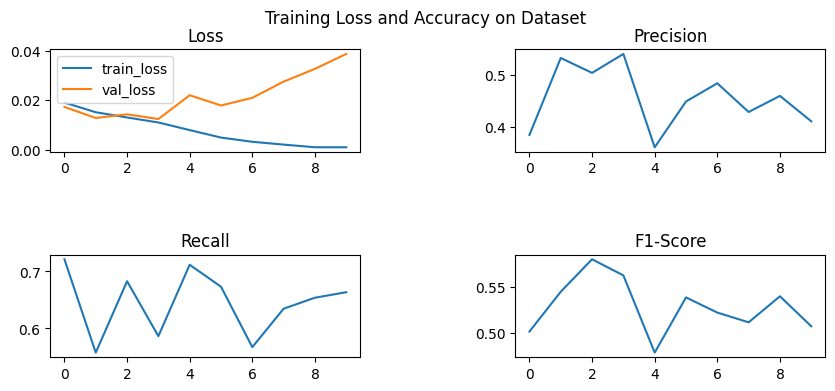

Validation: 100%|██████████| 18/18 [00:09<00:00,  1.95it/s, val_loss=0.0387]


[[360  99]
 [ 35  69]]


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 4))
fig.suptitle("Training Loss and Accuracy on Dataset")

axes[0][0].plot(np.arange(0, EPOCHS), history["train_loss"], label="train_loss")
axes[0][0].plot(np.arange(0, EPOCHS), history["val_loss"], label="val_loss")
axes[0][0].set_title('Loss')
axes[0][0].legend()

axes[0][1].plot(np.arange(0, EPOCHS), history["precision"], label="precision")
axes[0][1].set_title('Precision')

axes[1][0].plot(np.arange(0, EPOCHS), history["recall"], label="recall")
axes[1][0].set_title('Recall')

axes[1][1].plot(np.arange(0, EPOCHS), history["f1"], label="f1-score")
axes[1][1].set_title('F1-Score')

fig.subplots_adjust(hspace=1, wspace=0.5)
plt.show()


# Validation progress bar
val_loss = 0.0
correct = 0
total = 0
all_val_labels = []
all_val_preds = []
val_pbar = tqdm(test_loader, desc='Validation')
model.eval()
with torch.no_grad():
    for data in val_pbar:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.unsqueeze(1).float() # Convert labels to float
        outputs = model(images)
        loss = loss_function(outputs, labels)

        val_loss += loss.item()

        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_val_labels.extend(labels.cpu().numpy())
        all_val_preds.extend(predicted.cpu().numpy())

        # Update validation progress bar
        val_pbar.set_postfix({
        'val_loss': f'{val_loss/(total):.4f}',
        })

val_loss = val_loss / total


# Calculate classification metrics
y_true = np.array(all_val_labels).flatten()
y_pred = np.array(all_val_preds).flatten()

cm = confusion_matrix(y_true, y_pred)
print()
print(cm)


### 6) Model Improvements
Apply and evaluate three improvements ideas that you mentioned in the Baseline CNN question (Step 4).
Implement each idea separately, train a model with that improvement, and report the performance of each model using the metrics from Step 5. As above, train using the data in /train and test using the data in /valid.


❓ Which model would you deploy? Why?  
✅ Your answer here

I would deploy the batch normalization model as, although it suffers from overfitting, it has a better final and average f1-score over all epochs than the other 2 models.

[INFO] training network...


Validation: 100%|██████████| 18/18 [00:11<00:00,  1.63it/s, val_loss=0.0158]



Epoch 1/10 | Train Loss: 0.0183 | Val Loss: 0.0158 | Precision: 0.4961 | Recall: 0.6058 | F1-Score: 0.5455

[INFO] saving checkpoint for epoch 1...


Validation: 100%|██████████| 18/18 [00:10<00:00,  1.64it/s, val_loss=0.0179]



Epoch 2/10 | Train Loss: 0.0148 | Val Loss: 0.0179 | Precision: 0.3431 | Recall: 0.6731 | F1-Score: 0.4545

[INFO] saving checkpoint for epoch 2...


...


Epoch 8/10 | Train Loss: 0.0010 | Val Loss: 0.0201 | Precision: 0.4539 | Recall: 0.6635 | F1-Score: 0.5391

[INFO] saving checkpoint for epoch 8...


Validation: 100%|██████████| 18/18 [00:10<00:00,  1.77it/s, val_loss=0.0252]



Epoch 9/10 | Train Loss: 0.0008 | Val Loss: 0.0252 | Precision: 0.3947 | Recall: 0.7212 | F1-Score: 0.5102

[INFO] saving checkpoint for epoch 9...


Validation: 100%|██████████| 18/18 [00:11<00:00,  1.61it/s, val_loss=0.0231]



Epoch 10/10 | Train Loss: 0.0005 | Val Loss: 0.0231 | Precision: 0.4424 | Recall: 0.7019 | F1-Score: 0.5428

[INFO] saving checkpoint for epoch 10...
[INFO] saving final model...


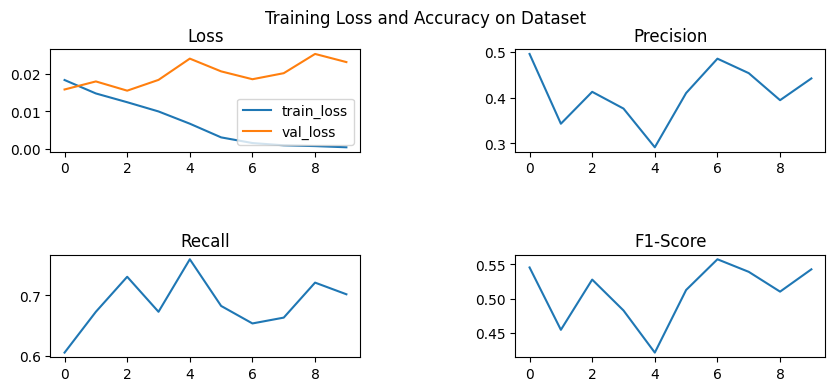

In [8]:
## Enter your code here..
class BatchNormCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2, 0))
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2, 0))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*32*32, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 1),
            nn.Sigmoid())


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x


#Initialize Model
batch_model = BatchNormCNN().to(device)

#Initialize Loss Function
loss_function = nn.BCELoss()

#Initialize Optimization function
optimizer = optim.Adam(
    batch_model.parameters(),
    lr=INIT_LEARNING_RATE
    )

batch_model, history = train_cnn(EPOCHS, BATCH_SIZE, INIT_LEARNING_RATE, batch_model, loss_function, optimizer, train_loader, test_loader)



fig, axes = plt.subplots(2, 2, figsize=(10, 4))
fig.suptitle("Training Loss and Accuracy on Dataset")

axes[0][0].plot(np.arange(0, EPOCHS), history["train_loss"], label="train_loss")
axes[0][0].plot(np.arange(0, EPOCHS), history["val_loss"], label="val_loss")
axes[0][0].set_title('Loss')
axes[0][0].legend()

axes[0][1].plot(np.arange(0, EPOCHS), history["precision"], label="precision")
axes[0][1].set_title('Precision')

axes[1][0].plot(np.arange(0, EPOCHS), history["recall"], label="recall")
axes[1][0].set_title('Recall')

axes[1][1].plot(np.arange(0, EPOCHS), history["f1"], label="f1-score")
axes[1][1].set_title('F1-Score')

fig.subplots_adjust(hspace=1, wspace=0.5)
plt.show()

[INFO] training network...


Validation: 100%|██████████| 18/18 [00:09<00:00,  1.99it/s, val_loss=0.0159]



Epoch 1/10 | Train Loss: 0.0180 | Val Loss: 0.0159 | Precision: 0.4493 | Recall: 0.5962 | F1-Score: 0.5124

[INFO] saving checkpoint for epoch 1...


Validation: 100%|██████████| 18/18 [00:10<00:00,  1.75it/s, val_loss=0.0128]



Epoch 2/10 | Train Loss: 0.0153 | Val Loss: 0.0128 | Precision: 0.5556 | Recall: 0.4327 | F1-Score: 0.4865

[INFO] saving checkpoint for epoch 2...


...


Epoch 8/10 | Train Loss: 0.0031 | Val Loss: 0.0589 | Precision: 0.3869 | Recall: 0.7404 | F1-Score: 0.5083

[INFO] saving checkpoint for epoch 8...


Validation: 100%|██████████| 18/18 [00:09<00:00,  1.98it/s, val_loss=0.0532]



Epoch 9/10 | Train Loss: 0.0021 | Val Loss: 0.0532 | Precision: 0.3936 | Recall: 0.7115 | F1-Score: 0.5068

[INFO] saving checkpoint for epoch 9...


Validation: 100%|██████████| 18/18 [00:09<00:00,  1.95it/s, val_loss=0.0706]



Epoch 10/10 | Train Loss: 0.0030 | Val Loss: 0.0706 | Precision: 0.4056 | Recall: 0.7019 | F1-Score: 0.5141

[INFO] saving checkpoint for epoch 10...
[INFO] saving final model...


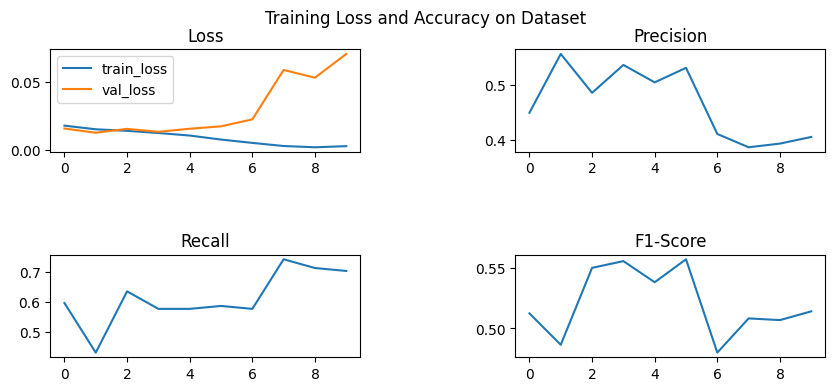

In [9]:
## Enter your code here..
class AddConvCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0))
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0))
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid())


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

#Initialize Model
add_conv_model = AddConvCNN().to(device)

#Initialize Loss Function
loss_function = nn.BCELoss()

#Initialize Optimization function
optimizer = optim.Adam(
    add_conv_model.parameters(),
    lr=INIT_LEARNING_RATE
    )

add_conv_model, history = train_cnn(EPOCHS, BATCH_SIZE, INIT_LEARNING_RATE, add_conv_model, loss_function, optimizer, train_loader, test_loader)



fig, axes = plt.subplots(2, 2, figsize=(10, 4))
fig.suptitle("Training Loss and Accuracy on Dataset")

axes[0][0].plot(np.arange(0, EPOCHS), history["train_loss"], label="train_loss")
axes[0][0].plot(np.arange(0, EPOCHS), history["val_loss"], label="val_loss")
axes[0][0].set_title('Loss')
axes[0][0].legend()

axes[0][1].plot(np.arange(0, EPOCHS), history["precision"], label="precision")
axes[0][1].set_title('Precision')

axes[1][0].plot(np.arange(0, EPOCHS), history["recall"], label="recall")
axes[1][0].set_title('Recall')

axes[1][1].plot(np.arange(0, EPOCHS), history["f1"], label="f1-score")
axes[1][1].set_title('F1-Score')

fig.subplots_adjust(hspace=1, wspace=0.5)
plt.show()

[INFO] training network...


Validation: 100%|██████████| 18/18 [00:06<00:00,  2.96it/s, val_loss=0.0212]



Epoch 1/10 | Train Loss: 0.0215 | Val Loss: 0.0212 | Precision: 0.6667 | Recall: 0.0192 | F1-Score: 0.0374

[INFO] saving checkpoint for epoch 1...


Validation: 100%|██████████| 18/18 [00:04<00:00,  4.43it/s, val_loss=0.0212]



Epoch 2/10 | Train Loss: 0.0215 | Val Loss: 0.0212 | Precision: 0.6667 | Recall: 0.0192 | F1-Score: 0.0374

[INFO] saving checkpoint for epoch 2...


...


Epoch 8/10 | Train Loss: 0.0215 | Val Loss: 0.0212 | Precision: 0.6667 | Recall: 0.0192 | F1-Score: 0.0374

[INFO] saving checkpoint for epoch 8...


Validation: 100%|██████████| 18/18 [00:04<00:00,  3.68it/s, val_loss=0.0212]



Epoch 9/10 | Train Loss: 0.0215 | Val Loss: 0.0212 | Precision: 0.6667 | Recall: 0.0192 | F1-Score: 0.0374

[INFO] saving checkpoint for epoch 9...


Validation: 100%|██████████| 18/18 [00:05<00:00,  3.38it/s, val_loss=0.0212]



Epoch 10/10 | Train Loss: 0.0215 | Val Loss: 0.0212 | Precision: 0.6667 | Recall: 0.0192 | F1-Score: 0.0374

[INFO] saving checkpoint for epoch 10...
[INFO] saving final model...


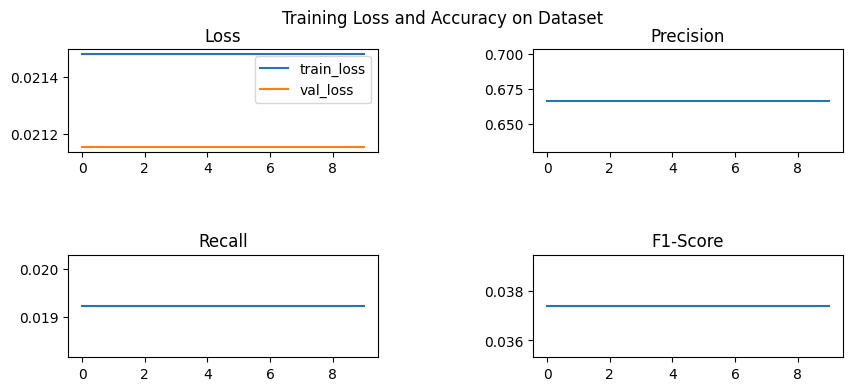

In [10]:
## Enter your code here..
class RemConvCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*64*64, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid())

    def forward(self, x):
        x = self.conv1(x)
        x = self.fc(x)
        return x

#Initialize Model
rem_conv_model = RemConvCNN().to(device)

#Initialize Loss Function
loss_function = nn.BCELoss()

#Initialize Optimization function
optimizer = optim.Adam(
    add_conv_model.parameters(),
    lr=INIT_LEARNING_RATE
    )

rem_conv_model, history = train_cnn(EPOCHS, BATCH_SIZE, INIT_LEARNING_RATE, rem_conv_model, loss_function, optimizer, train_loader, test_loader)



fig, axes = plt.subplots(2, 2, figsize=(10, 4))
fig.suptitle("Training Loss and Accuracy on Dataset")

axes[0][0].plot(np.arange(0, EPOCHS), history["train_loss"], label="train_loss")
axes[0][0].plot(np.arange(0, EPOCHS), history["val_loss"], label="val_loss")
axes[0][0].set_title('Loss')
axes[0][0].legend()

axes[0][1].plot(np.arange(0, EPOCHS), history["precision"], label="precision")
axes[0][1].set_title('Precision')

axes[1][0].plot(np.arange(0, EPOCHS), history["recall"], label="recall")
axes[1][0].set_title('Recall')

axes[1][1].plot(np.arange(0, EPOCHS), history["f1"], label="f1-score")
axes[1][1].set_title('F1-Score')

fig.subplots_adjust(hspace=1, wspace=0.5)
plt.show()

---

### 7) Personal Inference Test
Test your trained model on at least FIVE new images (either collected using a camera or collected from the internet). Predict whether each image contains a fire hydrant and print the result.

Of your five images:
- Include at least one image of a fire hydrant that your model does not detect correctly.
- Include at least one image of a fire hydrant that your model does detect correctly.

❓ Challenge: Can you find an image that does not actually contain a fire hydrant, but your model believes that a hydrant is present?

✅ Your answer here

Yes, in fact every picture I chose with no fire hydrant failed.

❓ Explain why you believe your model performed the way it did on each of your five images. What patterns or mistakes do you observe?

✅ Your answer here

I think the reason that most of the time the model predicted that there was a fire hydrant, even when there wasn't, was because in every image it predicted there was a tall cylindrical object that stood out against the image background.This would also make sense considering the resized 128x128 images would be much lower quality so it is possible that the model simply associated any long vertical object as a fire hydrant.

I think there are a few possible reasons why the model missed Hydrant4.png. For one, the image is much wider than the other images and the hydrant, nor any other cylindrical objects, are near the center focus, possibly leading to warping of the hydrant's shape. The hydrant also is fairly low resolution in the image so significant deatil may have been lost when the image was resized. Lastly, the bush behind the hydrant may have generated a lot of noise which may have confused the model into not recognizing the hydran't shape.

In [12]:
## Assume we mean the original trained model
extra_path = "/content/images"

imgs = ["NoHydrant.png", "Bollard.png", "Hydrant1.png", "Hydrant2.png", "Hydrant3.jpg", "Hydrant4.png", "NoHydrant2.png"]
testX = []
testY = [0, 0, 1, 1, 1, 1, 0]

for i in range(len(imgs)):
   temp = Image.open(os.path.join(extra_path, imgs[i]))
   temp = temp.convert('RGB')
   testX.append(transform(temp))

testY = torch.tensor(testY)

testing_set = list(zip(testX, testY))

test_loader = DataLoader(testing_set, batch_size=32, shuffle=False, num_workers=2)

# Validation progress bar
val_loss = 0.0
correct = 0
total = 0
all_val_labels = []
all_val_preds = []
val_pbar = tqdm(test_loader, desc='Validation')
model.eval()
with torch.no_grad():
    for data in val_pbar:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.unsqueeze(1).float() # Convert labels to float
        outputs = model(images)
        loss = loss_function(outputs, labels)

        val_loss += loss.item()

        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_val_labels.extend(labels.cpu().numpy())
        all_val_preds.extend(predicted.cpu().numpy())

        # Update validation progress bar
        val_pbar.set_postfix({
        'val_loss': f'{val_loss/(total):.4f}',
        })

val_loss = val_loss / total

y_true = np.array(all_val_labels).flatten()
y_pred = np.array(all_val_preds).flatten()

print()
for i in range(len(imgs)):
  print(f"{imgs[i]}  predicted label: {y_pred[i]}, actual label: {y_true[i]}")

Validation: 100%|██████████| 1/1 [00:00<00:00,  3.57it/s, val_loss=0.1566]


NoHydrant.png  predicted label: 1.0, actual label: 0.0
Bollard.png  predicted label: 0.0, actual label: 0.0
Hydrant1.png  predicted label: 1.0, actual label: 1.0
Hydrant2.png  predicted label: 1.0, actual label: 1.0
Hydrant3.jpg  predicted label: 1.0, actual label: 1.0
Hydrant4.png  predicted label: 0.0, actual label: 1.0
NoHydrant2.png  predicted label: 0.0, actual label: 0.0


---

### 8) (Optional) Transfer Learning with Pretrained CNN

#### Description:
In this optional step, fine-tune a pretrained CNN (e.g., ResNet50) on your dataset and compare its performance to your custom CNN.

- Use `torchvision.models.resnet50(pretrained=True)` as a starting model.

Reference: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
- Modify the final layer to fit your binary classification task (fire hydrant vs. no fire hydrant).
- Resize input images to **256x256** pixels.
- Fine-tune the model and evaluate its performance.
- Compare the results to your custom CNN in terms of accuracy, training time, and other relevant metrics.

#### Libraries to use:
```python
import torchvision.models as models
```

#### Student Code:
```python
# Your code here
```


------

### 9) Final Thoughts
❓ How would you improve the model in the future?

✅ Your answer here..

I think I would probably include more techniques to improve generalization such as batch normalization and Dropout as well as institute more layers as it seems as though more layers are better for solving this problem. I think also outside of the model that there could be some improvements to the data gathered, ideally with a more balanced dataset and also equally sized images to prevent resizing distortion. Maintaining a larger sized image as an input may also help.

-----

## Final Question:
### ❓ Did you use an AI tool in completing your assignment? If yes, which AI tool(s) did you use? How did you prompt it? How you validate the response?

✅ Your answer here..

Yes, I did use the built in Gemini feature to help identify some bugs in the code. I validating it by cross referencing it's suggestions with Tutorial materials and also some other online references such as pytorch documentation.

---

## Submission
Submit your `.ipynb` notebook on Brightspace using the following name format:  
`SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb`

